# Kuvantunnistus omilla kuvilla - CNN

## Datan ymmärrys
Datasetti sisältää yhtensä 478 kuvaa ja kuusi luokkaa. Kuvien luokat ja niiden kuvamäärät ovat seuraavat:
- Omena: 52 kuvaa
- Avokaado: 50 kuvaa
- Banaani: 104 kuvaa
- Viinirypäle: 66 kuvaa
- Kiivi: 50 kuvaa
- Appelsiini: 158 kuvaa

## Datan esikäsittely
Kuvadata on jaettu valmiiksi 70%, 15%, 15% jaolla testi- validointi- ja koulutushakemistoon. Valmiin hakemistorakenteen avulla voidaan ladata data suoraan kolmeksi Dataset-olioksi `tf.keras.preprocessing.image_dataset_from_directory`-funktiolla. Funktion parametreina annetaan hakemistojen polku, kuvien koko, eräkoko, labelien muoto ja sekoitus, jolloin data kuvat sekoitetaan.  Eräkoko määritetään jo tässä vaiheessa, jolloin datasetti palauttaa erissä 32 kuvaa ja niiden vastaavat luokat. Tämän takia eräkokoa ei tarvitse määrittää enää mallin koulutuksen yhteydessä. 

Datasetti normalisoidaan jakamalla kuvat 255:llä. Datasetti jaetaan koulutus-, validointi- ja testidatasetteihin 70%, 15% ja 15% suhteessa.

In [1]:
import tensorflow as tf
import numpy as np
from numpy.f2py.crackfortran import verbose
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, \
    RandomZoom
import random

batch_size = 32
img_size = (224, 224)
split_ratio = [0.7, 0.15, 0.15]

# Ladataan datasetti
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

class_names = dataset.class_names

# Normalisoidaan kuvat
dataset = dataset.map(lambda x, y: (x / 255.0, y))

dataset_size = len(dataset)

train_size = int(split_ratio[0] * dataset_size)
val_size = int(split_ratio[1] * dataset_size)

train_dataset = dataset.take(train_size)
validation_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)

# Tarkistetaan datasetin koko
print(
    f"Train batches: {len(train_dataset)}, Validation batches: {len(validation_dataset)}, Test batches: {len(test_dataset)}")


2025-04-02 09:13:41.772851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743585221.903237    1706 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743585221.938849    1706 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743585222.280539    1706 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743585222.280583    1706 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743585222.280587    1706 computation_placer.cc:177] computation placer alr

Found 478 files belonging to 6 classes.


I0000 00:00:1743585225.823083    1706 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Train batches: 10, Validation batches: 2, Test batches: 3


In [2]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
])

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    data_augmentation,
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_dataset, validation_data=validation_dataset, epochs=10, verbose=0)

/home/samul/anaconda3/envs/keras/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1743585229.414675    1809 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1743585230.606190    1809 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x9695710


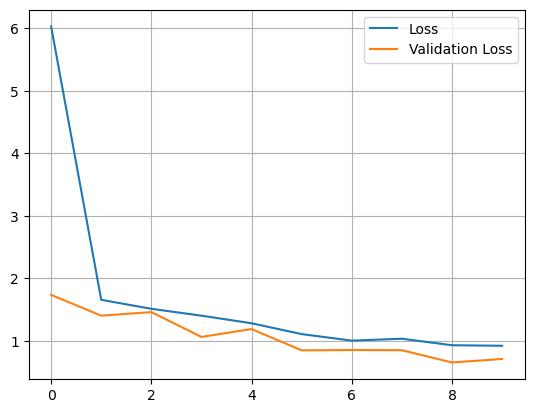

In [3]:
import matplotlib.pyplot as plt


def plot_loss(history):
    plt.plot(history.history["loss"], label="Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()


plot_loss(history)

In [4]:
def print_test_loss_accuracy(model):
    score = model.evaluate(test_dataset)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])

print_test_loss_accuracy(model)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8094 - loss: 0.6875
Test loss: 0.6531118750572205
Test accuracy: 0.8297872543334961


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


2025-04-02 09:13:58.583954: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


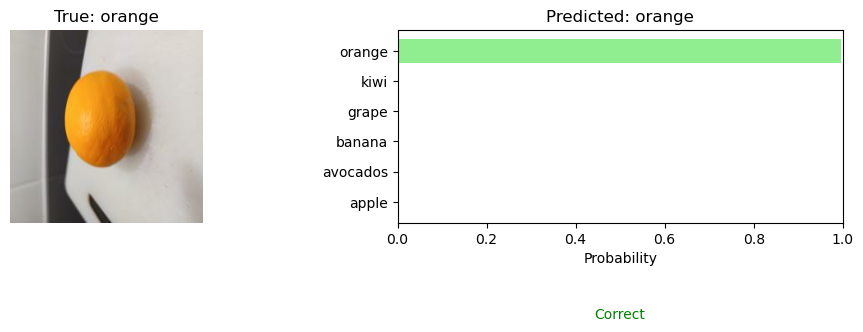

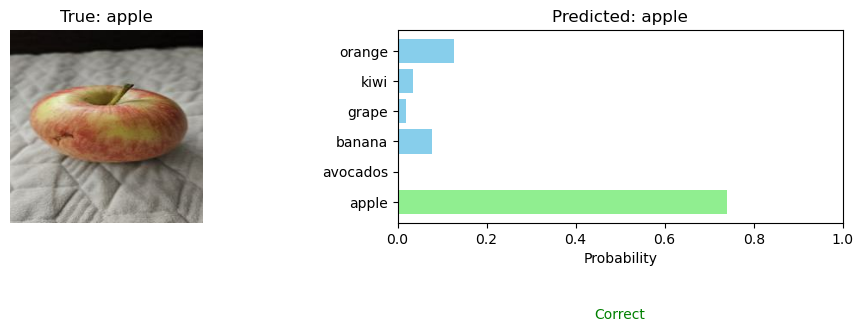

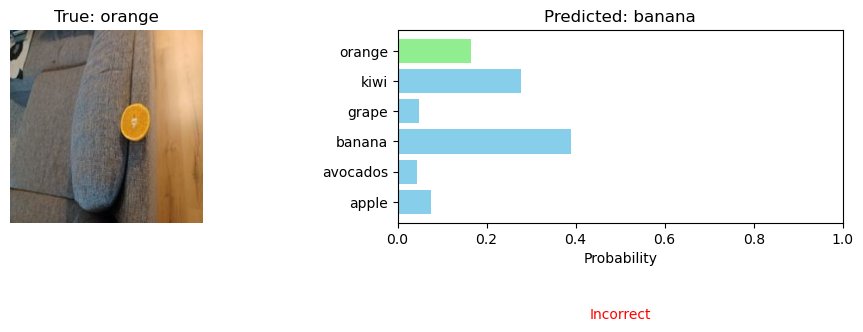

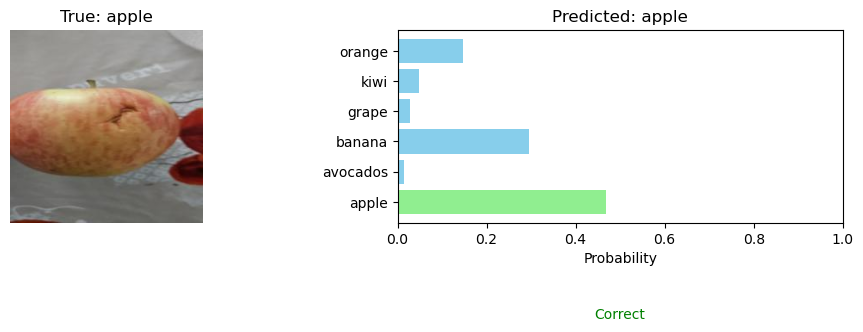

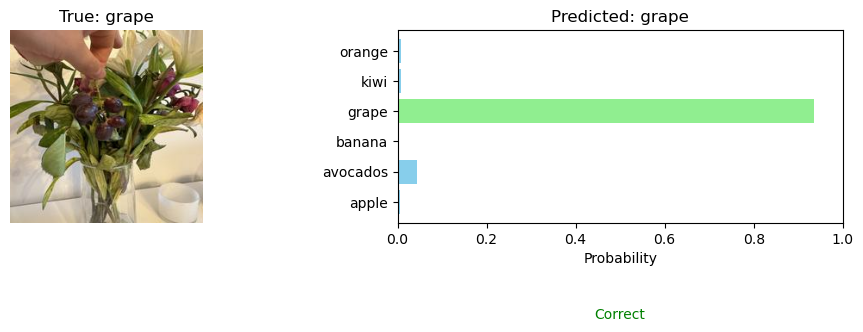

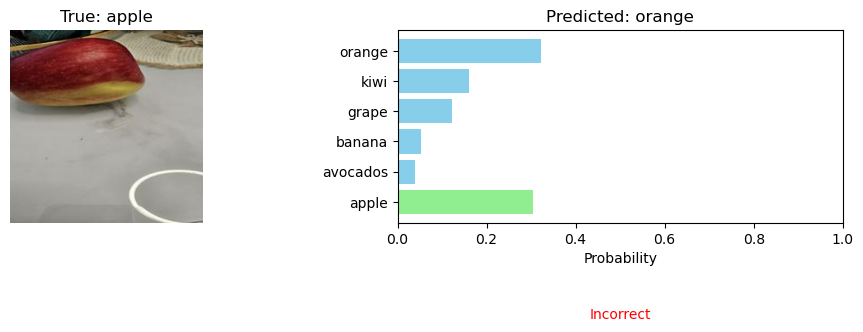

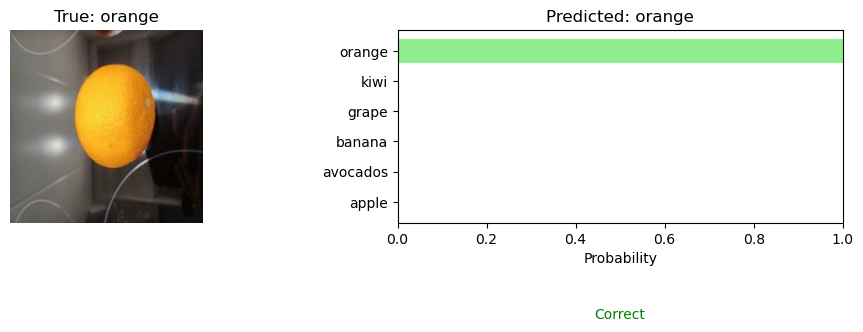

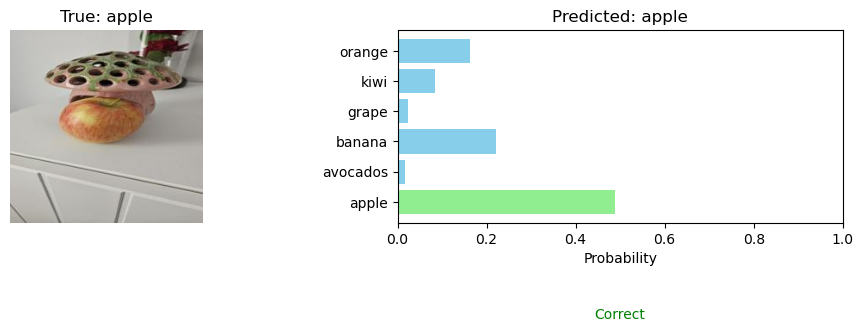

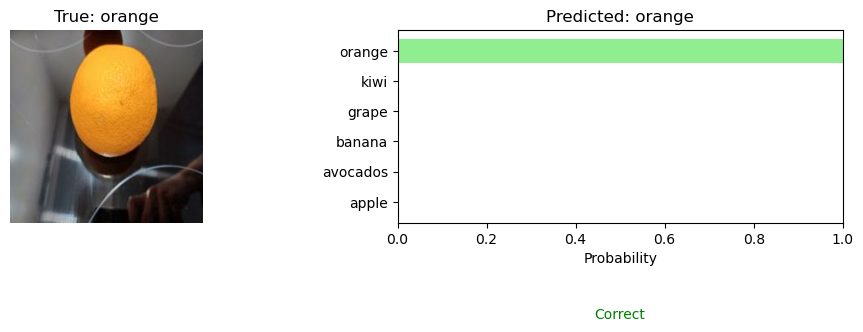

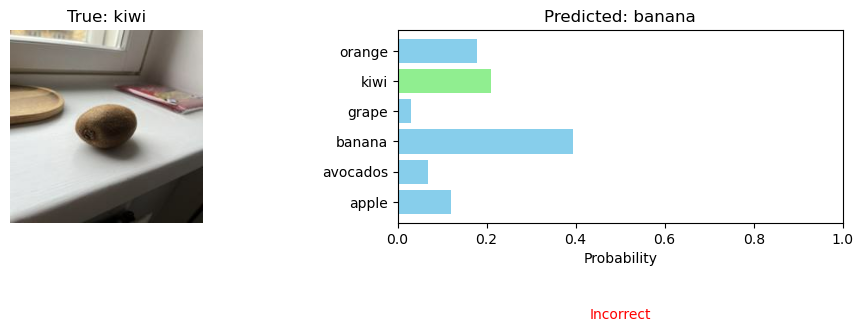

In [5]:
# Haetaan testidatasetista yksi batch
test_images, test_labels = next(iter(test_dataset.take(1)))

# Ennustetaan mallilla
predictions = model.predict(test_images)

# Muunnetaan one-hot-enkoodatut labelit kokonaisluvuiksi
true_labels = np.argmax(test_labels, axis=1)
predicted_labels = np.argmax(predictions, axis=1)


def plot_images(model):
    y_pred = []
    x_images = []
    y_true = []

    for images, labels in test_dataset:
        y_pred.extend(model.predict(images, batch_size=32))
        x_images.extend(images.numpy())
        y_true.extend(labels.numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    x_images = np.array(x_images)

    num_samples = 10
    random_indices = random.sample(range(len(x_images)), num_samples)

    for i in random_indices:
        plt.figure(figsize=(10, 4))

        # Display image
        plt.subplot(1, 2, 1)
        plt.imshow((x_images[i] * 255).astype("uint8"))
        true_class = class_names[np.argmax(y_true[i])]
        plt.title(f"True: {true_class}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        pred_prob = y_pred[i]
        predicted_class = class_names[np.argmax(pred_prob)]

        colors = ['lightgreen' if (class_names[idx] == true_class) else 'skyblue'
                  for idx in range(len(class_names))]

        plt.barh(class_names, pred_prob, color=colors)
        plt.xlabel('Probability')
        plt.title(f"Predicted: {predicted_class}")
        plt.xlim([0, 1])

        if predicted_class != true_class:
            plt.text(0.5, -0.5, "Incorrect", color='red',
                     ha='center', transform=plt.gca().transAxes)
        else:
            plt.text(0.5, -0.5, "Correct", color='green',
                     ha='center', transform=plt.gca().transAxes)

        plt.tight_layout()
        plt.show()


plot_images(model)

# Kuvantunnistus omilla kuvilla - VGG16 Assisted
Luodaan malli VGG16:n avulla, joka on esikoulutettu ImageNet-datasetillä. Mallista jätetään pois viimeinen kerros, koska sen halutaan sopivan omaan datasettiin. Mallin kerrokset jäädytetään, jotta niitä ei kouluteta uudelleen. Mallin päälle lisätään oma toteutus.

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg16_base.trainable = False

Luodaan omat kerrokset VGG16-mallin päälle. Mallin rakenne on seuraava:
- GlobalAveragePooling2D
- Dense(256, activation='relu')
- Dense(128, activation='relu', kernel_regularizer=l2(0.01))
- Dense(128, activation='relu')
- Dropout(0.2)
- Dense(6, activation='softmax')

In [7]:
x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(6, activation='softmax')(x)

Rakennetaan malli VGG16:n ja omien kerrosten avulla. Mallin optimointimenetelmänä käytetään Adamia, häviönä categorical_crossentropy ja mittarina tarkkuus.
Koulutetaan mallia 10 epookkia, eräkoolla 32.

In [8]:
model2 = Model(inputs=vgg16_base.input, outputs=predictions)

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(train_dataset, validation_data=validation_dataset, epochs=10, verbose=0)

I0000 00:00:1743585241.560665    1805 service.cc:152] XLA service 0xce42a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743585241.560698    1805 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2025-04-02 09:14:01.639481: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-02 09:14:03.187972: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_702', 188 bytes spill stores, 188 bytes spill loads

2025-04-02 09:14:03.702418: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1629', 36 bytes spill stores, 44 bytes spill loads

2025-04-02 09:14:03.793239: I external/

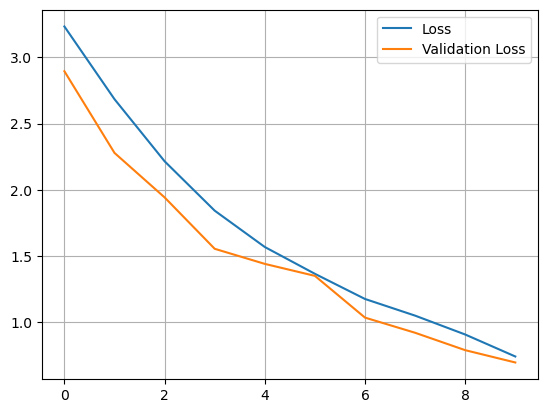

In [9]:
plot_loss(history2)

## Mallin Tarkkuuden arvointi
VGG-mallin tarkkuus testidatalla on noin 85% - 90%, joka on parempi kuin ensimmäisen.

In [10]:
print_test_loss_accuracy(model2)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9688 - loss: 0.6727

2025-04-02 09:14:17.759952: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 4 bytes spill stores, 4 bytes spill loads

2025-04-02 09:14:18.071945: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 200 bytes spill stores, 200 bytes spill loads

2025-04-02 09:14:18.961428: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_262', 4 bytes spill stores, 4 bytes spill loads

2025-04-02 09:14:19.428763: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_255', 12 bytes spill stores, 12 bytes spill loads



3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.9234 - loss: 0.7298
Test loss: 0.7613371014595032
Test accuracy: 0.8936170339584351


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


2025-04-02 09:14:27.739295: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


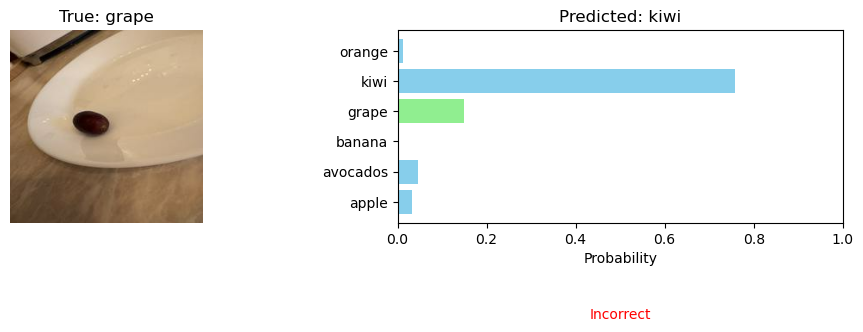

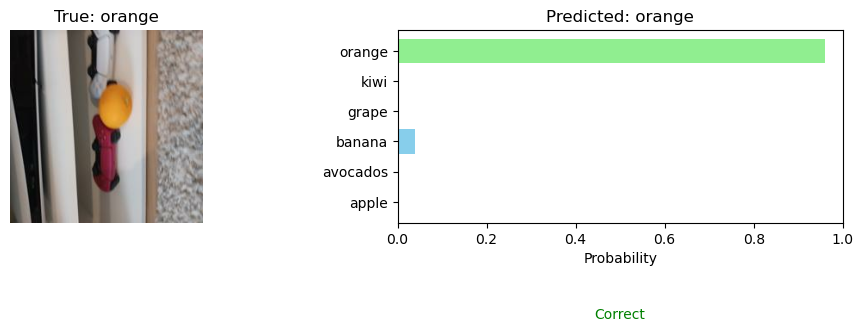

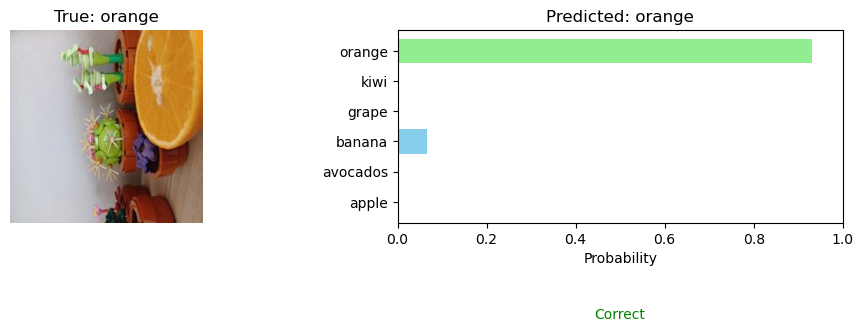

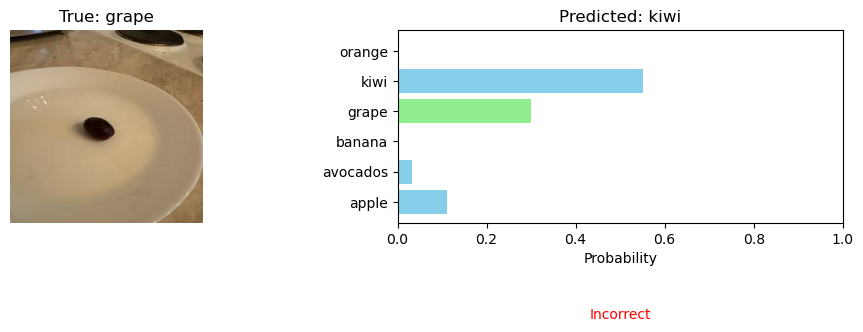

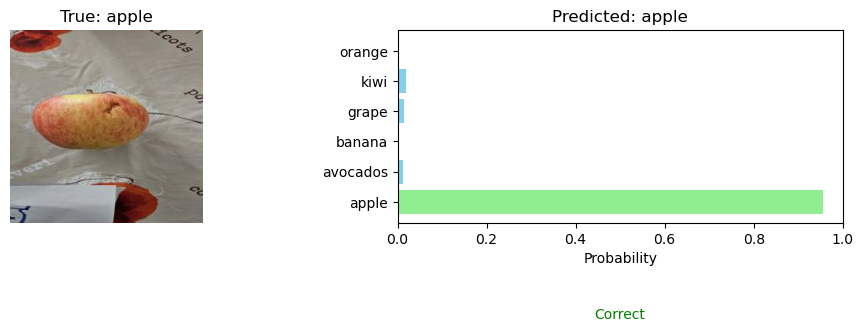

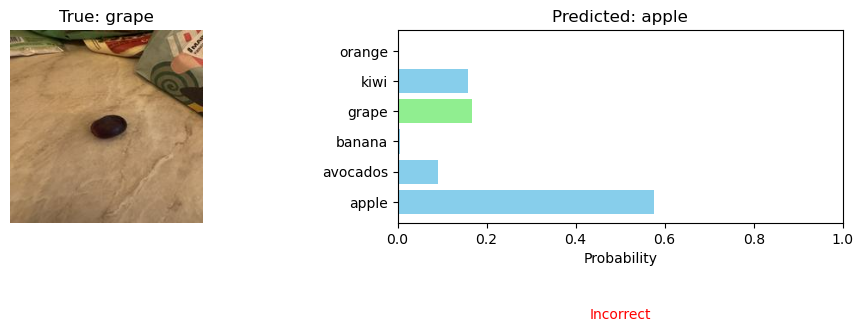

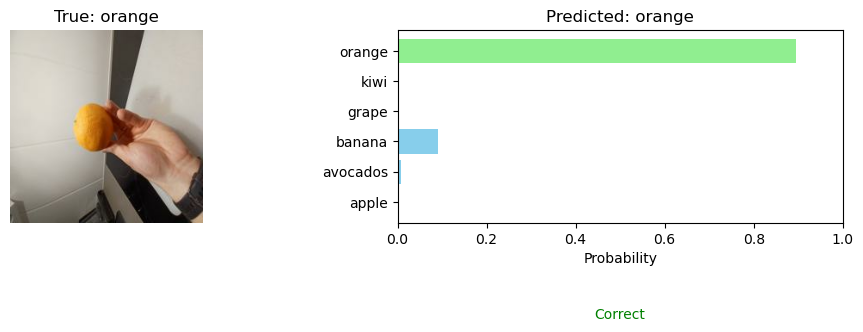

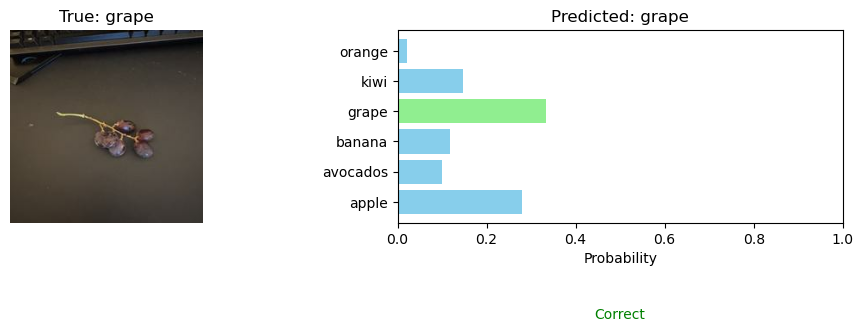

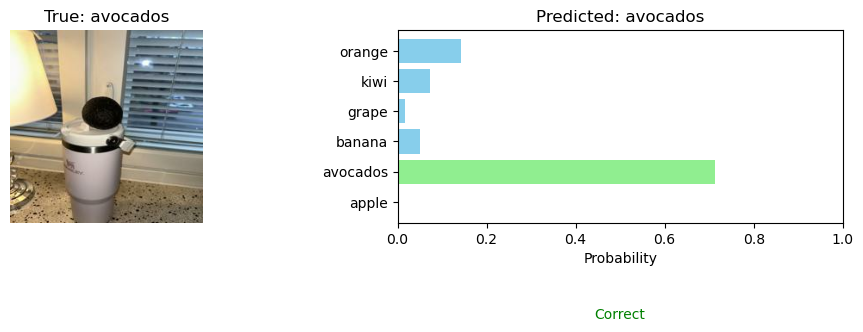

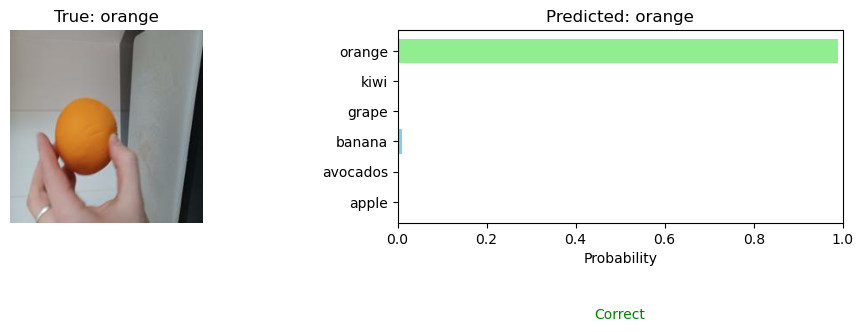

In [11]:
plot_images(model2)

# Hienosäädetty esikoulutettu malli VGG16

In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 base model
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze initial layers and unfreeze later ones for fine-tuning
for layer in vgg16_base.layers[:15]:  # Freeze first 15 layers
    layer.trainable = False
for layer in vgg16_base.layers[15:]:  # Unfreeze last few layers
    layer.trainable = True

# Add custom layers
x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

# Create model
model3 = Model(inputs=vgg16_base.input, outputs=predictions)

model3.summary()

# Use lower learning rate for fine-tuning
optimizer = Adam(learning_rate=0.0001)

model3.compile(optimizer=optimizer,
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Train with callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.1, patience=3)
]

history3 = model3.fit(train_dataset,
                      validation_data=validation_dataset,
                      epochs=30,  # More epochs for fine-tuning
                      callbacks=callbacks)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 7,212,294 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.2746 - loss: 1.7484 - val_accuracy: 0.6250 - val_loss: 1.0336 - learning_rate: 1.0000e-04
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5925 - loss: 1.0491 - val_accuracy: 0.7969 - val_loss: 0.7246 - learning_rate: 1.0000e-04
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.6848 - loss: 0.7873 - val_accuracy: 0.8906 - val_loss: 0.3851 - learning_rate: 1.0000e-04
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8302 - loss: 0.5290 - val_accuracy: 0.9531 - val_loss: 0.2477 - learning_rate: 1.0000e-04
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9105 - loss: 0.3104 - val_accuracy: 1.0000 - val_loss: 0.1014 - learning_rate: 1.0000e-04
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9115 - loss: 0.2857 - val_accuracy: 0.9844 - val_loss: 0.1117 - learning_rate: 1.0000e-04
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9352

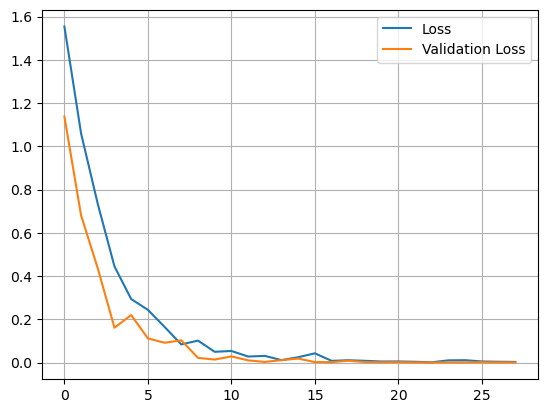

In [13]:
plot_loss(history3)

In [14]:
print_test_loss_accuracy(model3)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 1.0000 - loss: 2.7272e-04

2025-04-02 09:14:57.644174: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_234', 4 bytes spill stores, 4 bytes spill loads



3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 719ms/step - accuracy: 1.0000 - loss: 1.8846e-04
Test loss: 0.00016102528024930507
Test accuracy: 1.0
